### Improved Model Development - Random Forest Model

### Export Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, RobustScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
%pip install shap
import shap
from sklearn.model_selection import RandomizedSearchCV
from matplotlib.colors import LinearSegmentedColormap
import joblib

Note: you may need to restart the kernel to use updated packages.


In [3]:
# Load the cleaned dataset

df_i = pd.read_csv('../data/processing/modeling_dataset.csv')

In [4]:
df_i['date'] = pd.to_datetime(df_i['date'])

In [5]:
df_i.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15500 entries, 0 to 15499
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ticker          15500 non-null  object        
 1   date            15500 non-null  datetime64[ns]
 2   sma_20          15500 non-null  float64       
 3   bb_width        15500 non-null  float64       
 4   volume_ratio    15500 non-null  float64       
 5   volume_sma_20   15500 non-null  float64       
 6   rsi_14          15500 non-null  float64       
 7   macd_histogram  15500 non-null  float64       
 8   true_range      15500 non-null  float64       
 9   volatility_20   15500 non-null  float64       
 10  momentum_10     15500 non-null  float64       
 11  sp500_close     15500 non-null  float64       
 12  nasdaq_close    15500 non-null  float64       
 13  vix_close       15500 non-null  float64       
 14  trend_label     15500 non-null  object        
dtypes:

In [6]:
df_i.head()

,ticker,date,sma_20,bb_width,volume_ratio,volume_sma_20,rsi_14,macd_histogram,true_range,volatility_20,momentum_10,sp500_close,nasdaq_close,vix_close,trend_label
0,STK001,2021-01-04,160.110000,6.363961,1.000000,962644.00,100.000000,0.000000,2.88,0.012463,-0.008557,3891.04,12952.02,20.48,Uptrend
1,STK001,2021-01-05,161.235000,6.363961,1.153842,1137664.50,100.000000,0.143590,5.39,0.012463,-0.008557,3847.20,13116.52,19.89,Sideways
2,STK001,2021-01-06,161.416667,4.672701,1.167277,1241502.00,79.505300,0.188720,1.57,0.012463,-0.008557,3878.24,12818.48,20.02,Sideways
3,STK001,2021-01-07,162.830000,11.933013,1.167320,1314834.75,92.857143,0.543952,6.12,0.018138,-0.008557,3803.95,13290.11,19.59,Downtrend
4,STK001,2021-01-08,163.400000,11.523437,0.694431,1221520.00,79.284963,0.647386,4.08,0.018663,-0.008557,3715.64,13365.73,20.14,Downtrend


### Random Forest Model

In [7]:
# Define Features and Target

target_col = 'trend_label'

# To exclude non-predictive columns
feature_cols = [col for col in df_i.columns if col not in ['ticker', 'date', target_col]]

# Temporal Split: 70% Train, 30% Test

split_date = df_i['date'].quantile(0.7)
train_df = df_i[df_i['date'] <= split_date].copy()
test_df  = df_i[df_i['date'] > split_date].copy()

# Encode categorical variable

target_encoder = LabelEncoder()
train_df['trend_label'] = target_encoder.fit_transform(train_df['trend_label'])
test_df['trend_label']  = target_encoder.transform(test_df['trend_label'])

# Scale numerical features

# Define numerical features
num_cols = df_i.select_dtypes(include=['int64', 'float64']).columns

scaler = RobustScaler()

train_df[num_cols] = scaler.fit_transform(train_df[num_cols])
test_df[num_cols]  = scaler.transform(test_df[num_cols])

# Split dataset
X_train = train_df[num_cols]
y_train = train_df[target_col]

X_test = test_df[num_cols]
y_tests = test_df[target_col]

# Handle class imbalance using SMOTE
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

In [8]:
# Build Random Forest Model
rf = RandomForestClassifier(n_estimators=100, max_depth=20, class_weight=None, random_state=42)

rf.fit(X_train_res, y_train_res)
pred_y = rf.predict(X_test)


# Model Evaluation
print('\nRandom Forest Classification Report (Baseline):\n', classification_report(y_tests, pred_y))


Random Forest Classification Report (Baseline):
               precision    recall  f1-score   support

           0       0.30      0.28      0.29      1354
           1       0.36      0.34      0.35      1579
           2       0.39      0.43      0.41      1707

    accuracy                           0.35      4640
   macro avg       0.35      0.35      0.35      4640
weighted avg       0.35      0.35      0.35      4640



### Observation of Findings

The baseline Random Forest model achieves an overall accuracy of ~35%, closely matching the logistic regression baseline. This indicates that both linear and non-linear models struggle, suggesting that the raw engineered features (before advanced feature engineering) do not yet capture enough predictive signal from market behaviour.

- Uptrend is the easiest class, with the highest recall (0.43) and F1 (0.41).
This means Random Forest can identify upward momentum slightly better than other patterns.

- Downtrend is the hardest, with the weakest F1-score (0.29), indicating the model struggles to detect downward reversals.

- Sideways trends remain difficult, consistent with financial time-series behaviour where consolidation periods often resemble noise.

**Model Capability Notes**

Random Forest performs slightly better than Logistic Regression in identifying Uptrends, confirming that non-linear relationships exist.

However, the improvement is not significant, meaning:

- Important predictors are still missing (lag features, momentum interactions, macro-volatility dynamics).

- The baseline model is capacity-limited due to unrefined features.

### Confusion Matrix

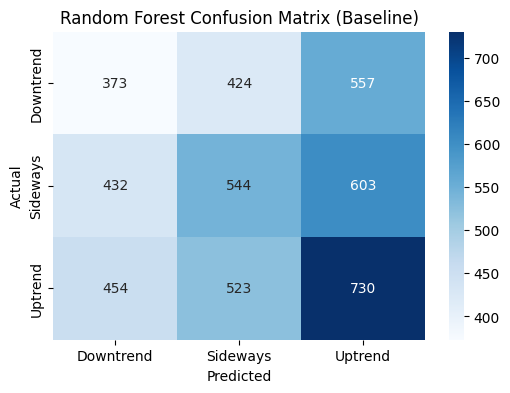

In [9]:
cm = confusion_matrix(y_tests, pred_y)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_encoder.classes_, yticklabels=target_encoder.classes_)
plt.title("Random Forest Confusion Matrix (Baseline)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Observation of Findings

The baseline Random Forest demonstrates limited predictive power across all classes, with significant overlap among trend patterns. Most notably, the model shows a strong tendency to over-predict Uptrend, suggesting that the baseline feature set does not provide enough discriminatory strength to separate the three trend categories. The confusion across Downtrend and Sideways also confirms that more informative features or temporal dynamics must be captured before a more accurate model can emerge.

### To Plot Precision, Recall & F1 by Class

In [11]:
# To generate classification report as a dictionary

report_dict = classification_report(y_tests, pred_y, output_dict=True)
df_report = pd.DataFrame(report_dict).T

# Extract only classes 0, 1, 2

df_scores = df_report.loc[['0', '1', '2'], ['precision', 'recall', 'f1-score']]
df_scores

,precision,recall,f1-score
0,0.296267,0.275480,0.285496
1,0.364856,0.344522,0.354397
2,0.386243,0.427651,0.405894


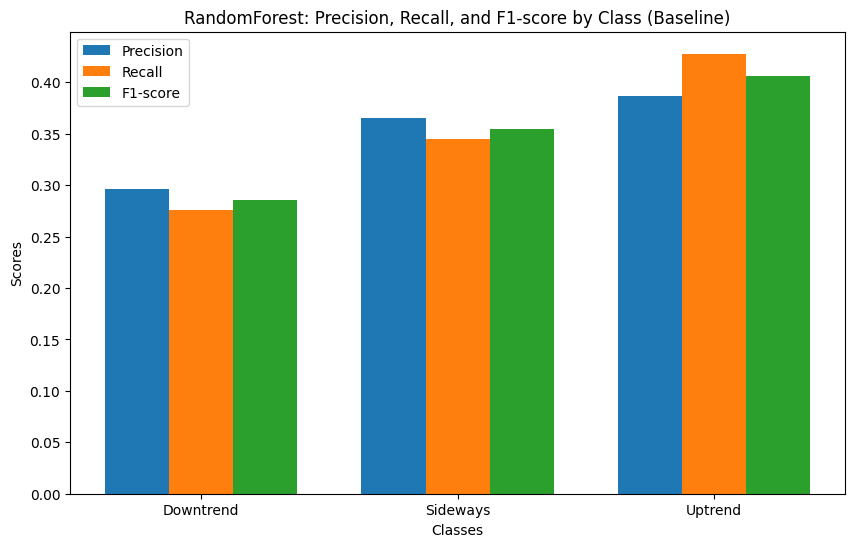

In [13]:
# To plt grouped barchart

# Data
metrics = ['precision', 'recall', 'f1-score']
classes = df_scores.index.tolist()
values = df_scores.values

# Bar positions
x = np.arange(len(classes))   # positions for classes: 0, 1, 2
width = 0.25                  # width of each bar

plt.figure(figsize=(10, 6))

# Plot bars
plt.bar(x - width, values[:, 0], width, label='Precision')
plt.bar(x,         values[:, 1], width, label='Recall')
plt.bar(x + width, values[:, 2], width, label='F1-score')

# Labels and title
class_labels = ['Downtrend', 'Sideways', 'Uptrend']

plt.xlabel("Classes")
plt.ylabel("Scores")
plt.title("RandomForest: Precision, Recall, and F1-score by Class (Baseline)")
plt.xticks(x, class_labels)
plt.legend()

plt.show()

### Observation of Findings

The chart compares precision, recall, and F1-score for the three target classes: Downtrend, Sideways, and Uptrend. Several important patterns emerge:

1. Uptrend Is the Easiest Class for Random Forest to Learn

- Highest precision (0.39) - When RF predicts Uptrend, it is correct more often than for other classes.

- Highest recall (0.43) - RF successfully captures more Uptrend samples than Downtrend or Sideways.

- Highest F1-score (0.41) - Indicates better balance of precision and recall.

Uptrend patterns appear more distinctive in your engineered features—possibly linked to volatility, momentum, or market-index shifts.

2. Sideways Performs Moderately Across All Metrics

- Precision = 0.36, Recall = 0.35, F1 = 0.36

Sideways trends are naturally harder to classify because they resemble noise or low-momentum movement, but RF handles them better than logistic regression.

However, performance remains modest—features may not capture congestion / consolidation patterns effectively.

3. Downtrend Is the Weakest Class

- Precision = 0.30, Recall = 0.28, F1 = 0.29

RF struggles to distinguish Downtrend vs. Sideways.

Overall, the Random Forest baseline model shows modest predictive capability, with the strongest detection of Uptrend patterns and the weakest on Downtrend classification. The overall performance (F1-scores around 0.29–0.41) confirms that the 12 baseline features contain useful—but insufficient—trend-discriminating information.

### Feature Engineering

In [14]:
# Extract Dates

df_i['day_of_week'] = df_i['date'].dt.dayofweek
df_i['quarter'] = df_i['date'].dt.quarter

# Create price lag
df_i['sma_return_1d'] = df_i['sma_20'].pct_change(1)
df_i['sma_return_2d'] = df_i['sma_20'].pct_change(2)
df_i['sma_return_7d'] = df_i['sma_20'].pct_change(7)

# Create return lag
df_i['sma_return_1d_lag1'] = df_i['sma_return_1d'].shift(1)
df_i['sma_return_1d_lag2'] = df_i['sma_return_1d'].shift(2)

# Create volatility lags
df_i['volatility_20_lag1'] = df_i['volatility_20'].shift(1)

# Create Indicator Lags
df_i['macd_histogram_lag1'] = df_i['macd_histogram'].shift(1)
df_i['rsi_14_lag1'] = df_i['rsi_14'].shift(1)

# Market Indices lags and return
df_i['sp500_return'] = df_i['sp500_close'].pct_change()
df_i['nasdaq_return'] = df_i['nasdaq_close'].pct_change()
df_i['vix_return'] = df_i['vix_close'].pct_change()

df_i['sp500_return_lag1'] = df_i['sp500_return'].shift(1)
df_i['nasdaq_return_lag1'] = df_i['nasdaq_return'].shift(1)
df_i['vix_return_lag1'] = df_i['vix_return'].shift(1)

df_i['sp500_5d_return'] = df_i['sp500_close'].pct_change(5)
df_i['nasdaq_5d_return'] = df_i['nasdaq_close'].pct_change(5)

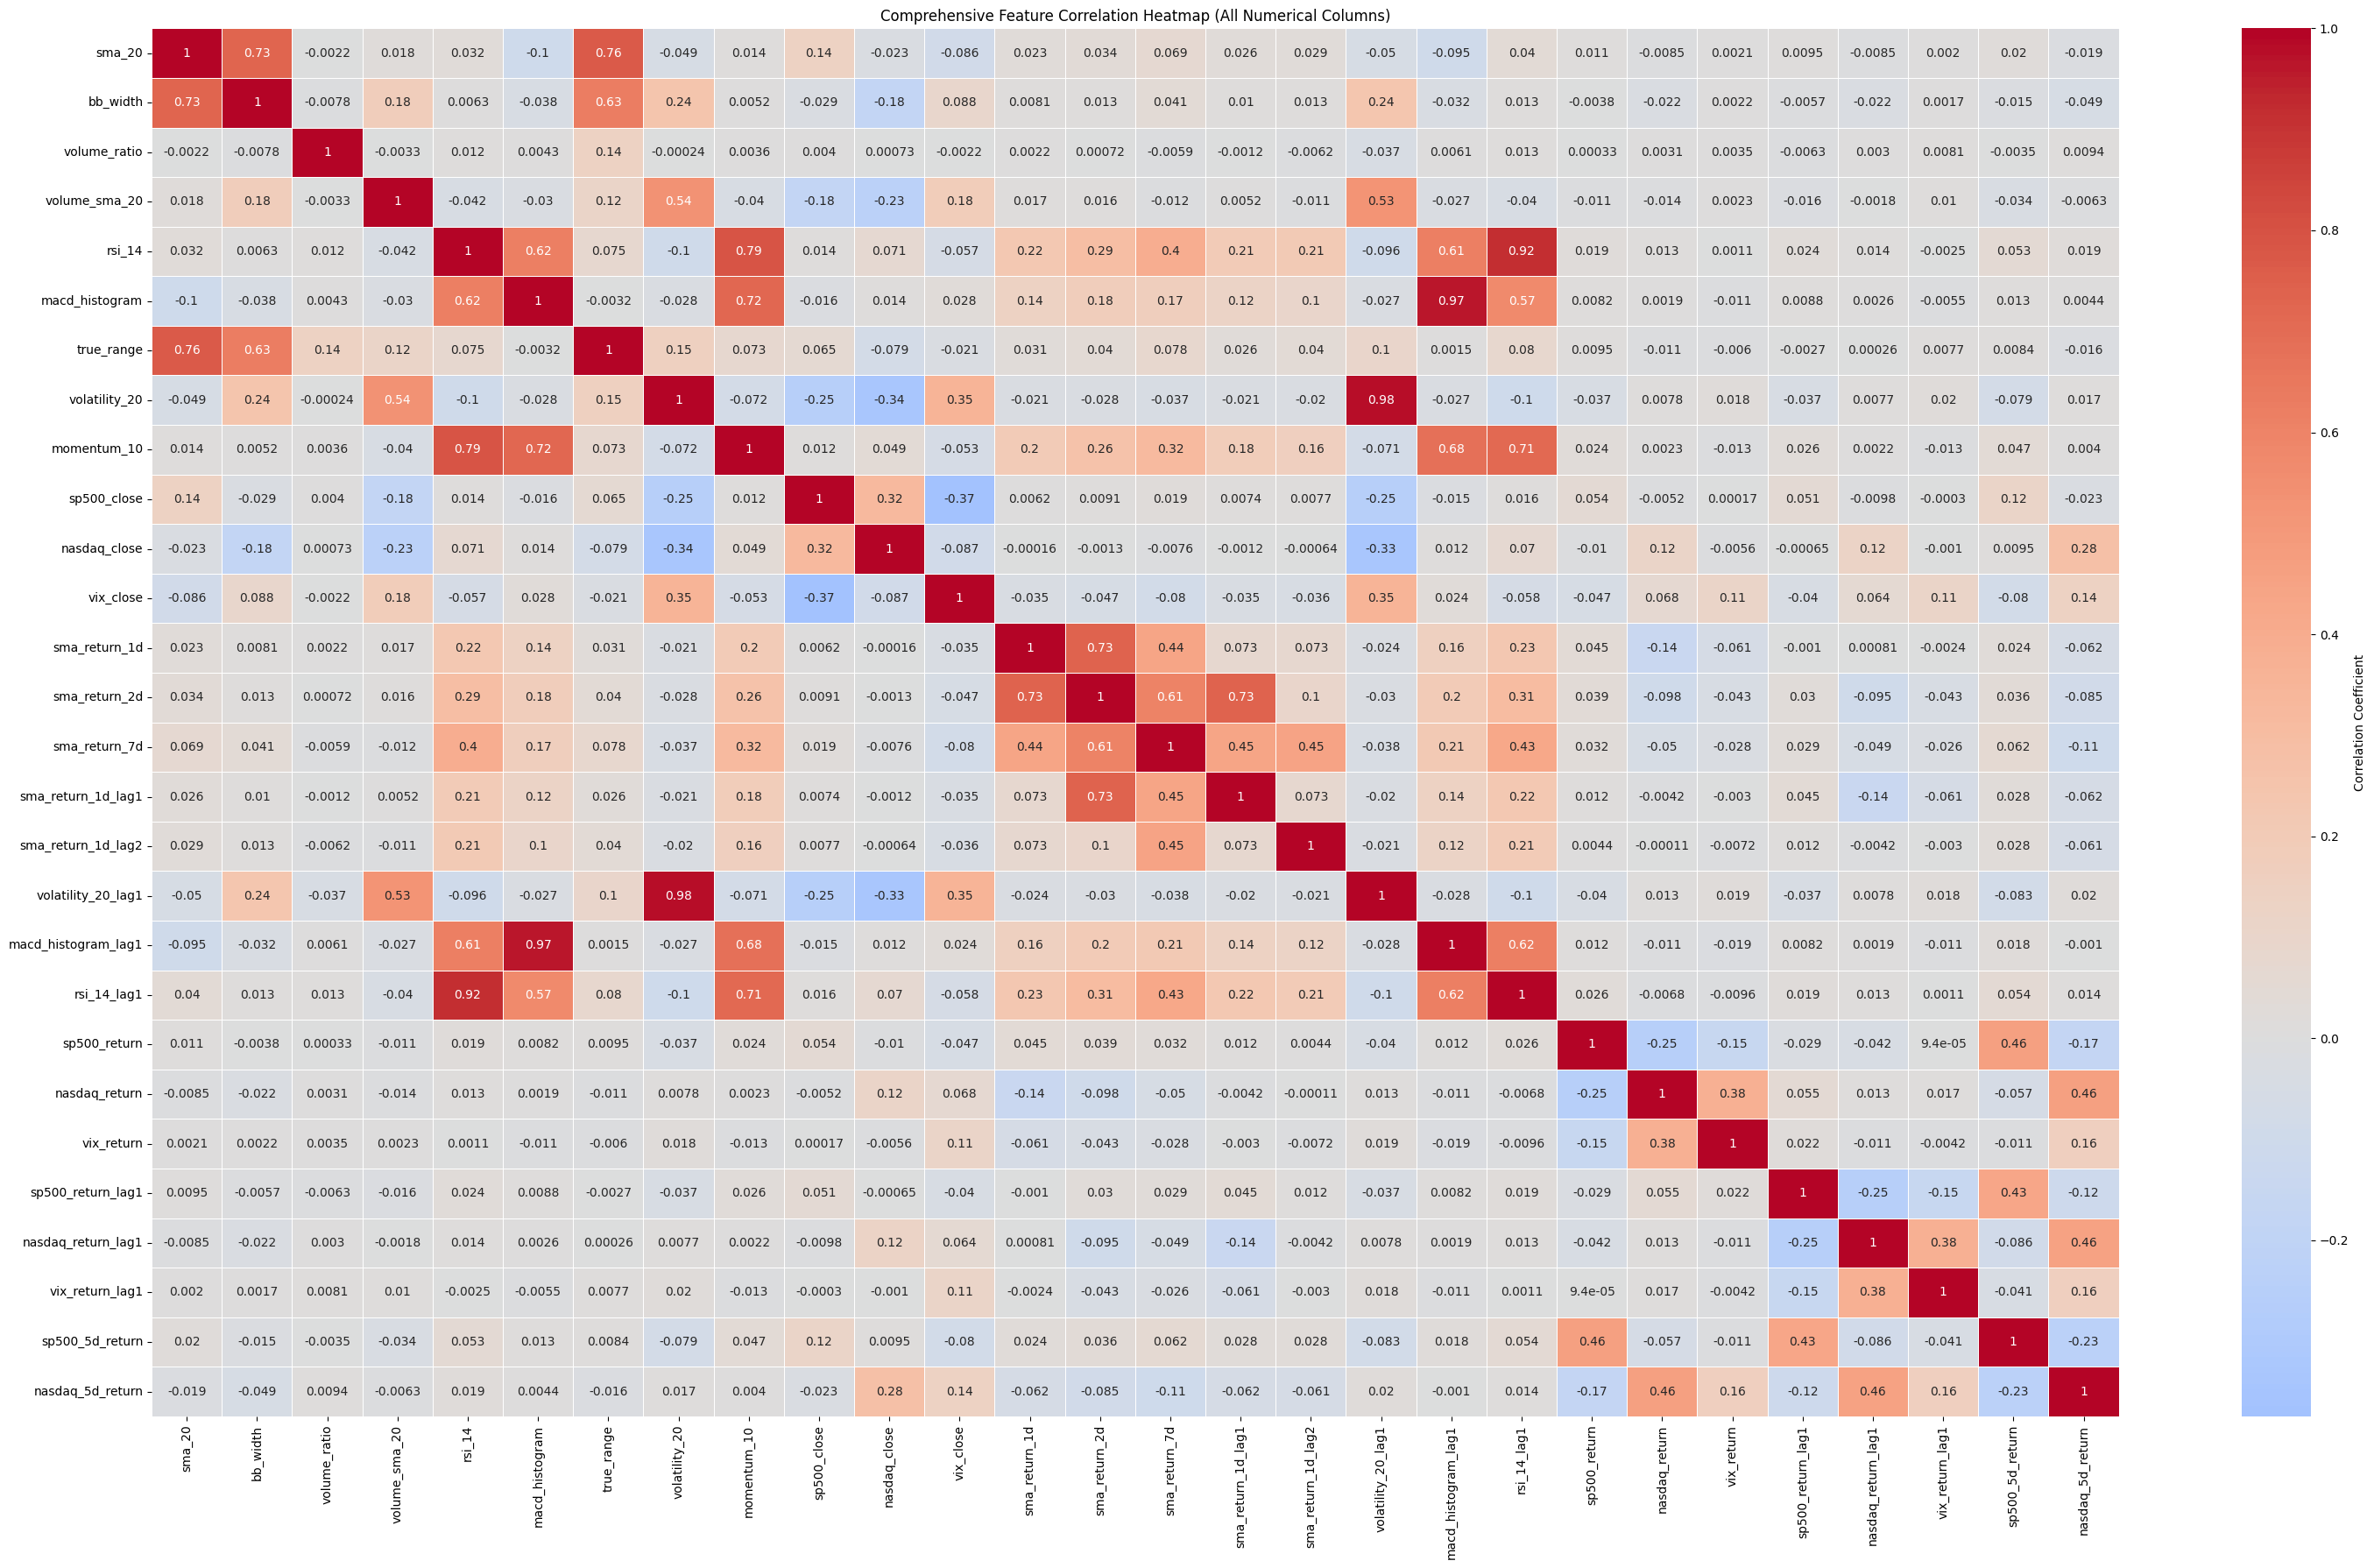

In [15]:
num_col = df_i.select_dtypes(include=['float64', 'int64'])

# Compute correlation matrix
corr_matrix = num_col.corr()

# Plot correlation heatmap
plt.figure(figsize=(30,18))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    annot=True, 
    center=0,
    linewidths=0.5,
    cbar_kws={'label': 'Correlation Coefficient'}
)
plt.title('Comprehensive Feature Correlation Heatmap (All Numerical Columns)')

plt.tight_layout()
plt.show()

### Observation of Findings

This was done to help narrow down vatiables that are not too correlated.

In [16]:
# Drop all correlated Features

df_i = df_i.drop(['sma_return_1d', 'sma_return_2d', 'sma_return_1d_lag1', 'rsi_14_lag1', 
                  'volatility_20_lag1', 'macd_histogram_lag1'], axis=1)

In [17]:
df_i.columns

Index(['ticker', 'date', 'sma_20', 'bb_width', 'volume_ratio', 'volume_sma_20',
       'rsi_14', 'macd_histogram', 'true_range', 'volatility_20',
       'momentum_10', 'sp500_close', 'nasdaq_close', 'vix_close',
       'trend_label', 'day_of_week', 'quarter', 'sma_return_7d',
       'sma_return_1d_lag2', 'sp500_return', 'nasdaq_return', 'vix_return',
       'sp500_return_lag1', 'nasdaq_return_lag1', 'vix_return_lag1',
       'sp500_5d_return', 'nasdaq_5d_return'],
      dtype='object')

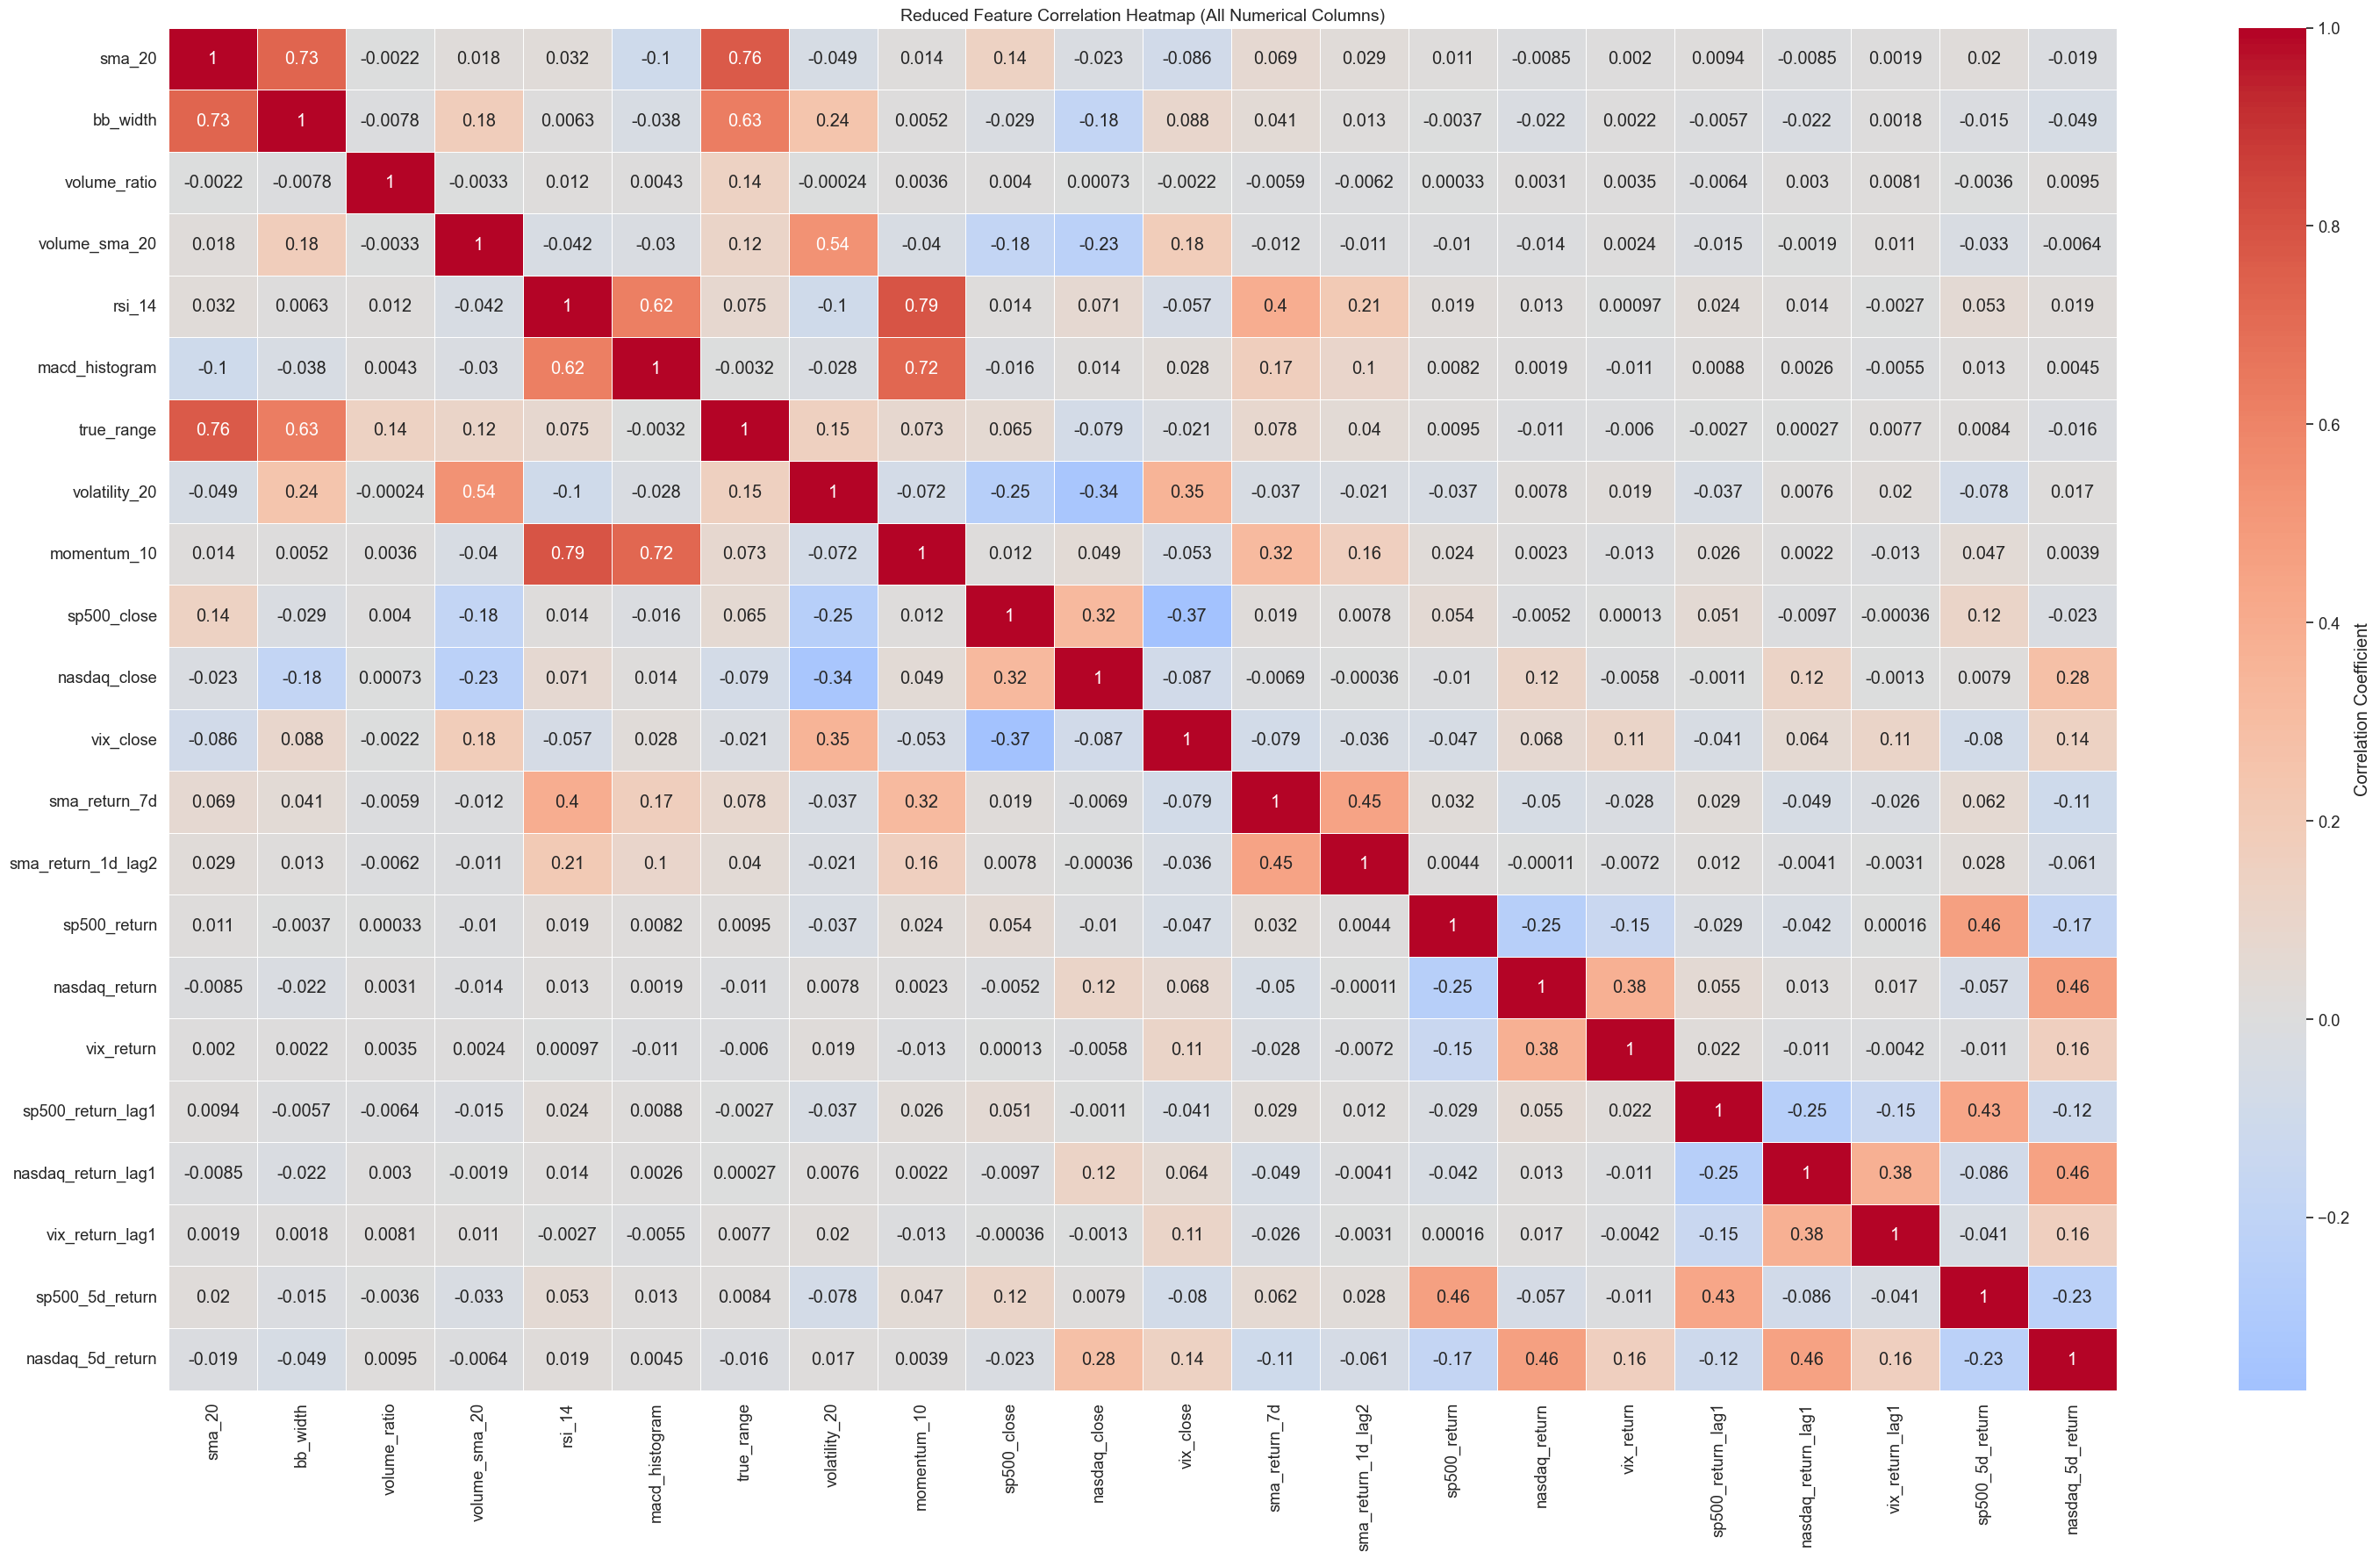

In [56]:
num_cols = df_i.select_dtypes(include=['float64', 'int64'])
# Compute correlation matrix
corr = num_cols.corr()

# Plot correlation heatmap
plt.figure(figsize=(30,18))
sns.heatmap(
# Select only numerical columns (exclude categorical or datetime)
    corr,
    cmap='coolwarm',
    annot=True, 
    center=0,
    linewidths=0.5,
    cbar_kws={'label': 'Correlation Coefficient'}
)
plt.title('Reduced Feature Correlation Heatmap (All Numerical Columns)', fontsize=14)

plt.savefig('../visuals/model_performance/reduced_correlation_heatmap.png', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

### Observation of Findings

The reduced feature set exhibits greatly improved correlation structure, with no severe multicollinearity present. The remaining features now offer diverse predictive information, balancing:

- Short-term technical indicators

- Momentum measures

- Macro-market signals

- Lagged temporal behavior

This refined dataset is now suitable for producing more stable, interpretable, and generalizable models in the improved-model stage.

### Variance Inflation Factor to Check for Multicollinearity

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

# Select only numeric features for VIF
X = df_i.select_dtypes(include=['float64', 'int64']).dropna()

# Scale data for numerical stability
X_scaled = StandardScaler().fit_transform(X)

# Compute VIF
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X_scaled, i) for i in range(X_scaled.shape[1])]

# Sort results
vif_data = vif_data.sort_values(by="VIF", ascending=True)

vif_data


,feature,VIF
2,volume_ratio,1.054451
18,vix_return_lag1,1.193517
15,vix_return,1.197019
12,sma_return_1d_lag2,1.263393
8,sp500_close,1.350488
10,vix_close,1.362410
9,nasdaq_close,1.392926
3,volume_sma_20,1.418979
16,sp500_return_lag1,1.440733
11,sma_return_7d,1.469089


### Observation of Findings

The VIF results show that most engineered features fall within acceptable multicollinearity ranges, with the majority having VIF values between 1.0 and 2.0, indicating low correlation and unique information contribution.

However, a few features demonstrated moderate multicollinearity:

- sma_20 (VIF = 4.17)
This is the most collinear feature in the dataset. SMA values tend to encode heavily smoothed price trends, which overlap with other momentum and volatility-derived indicators.

- true_range (VIF = 2.85)
This suggests shared information with volatility indicators (e.g., ATR-based signals and VIX series). It is not problematic but confirms overlapping representation of volatility.

- bb_width (VIF = 2.66)
Bollinger Band width correlates with volatility measures, especially the 20-day volatility feature. The moderate VIF indicates redundancy, but still within an acceptable threshold.

- rsi_14 (VIF = 1.95) & volatility_20 (VIF ≈ 1.94) - Indicators capture trend strength and market variability; minor collinearity is expected.

Overall, none of the features exceeded the critical VIF threshold (10).
Thus, severe multicollinearity is not present, and the selected features are suitable for modeling after removing the highly correlated variables identified during correlation filtering.

In [19]:
df_i.isna().sum()

ticker                0
date                  0
sma_20                0
bb_width              0
volume_ratio          0
volume_sma_20         0
rsi_14                0
macd_histogram        0
true_range            0
volatility_20         0
momentum_10           0
sp500_close           0
nasdaq_close          0
vix_close             0
trend_label           0
day_of_week           0
quarter               0
sma_return_7d         7
sma_return_1d_lag2    3
sp500_return          1
nasdaq_return         1
vix_return            1
sp500_return_lag1     2
nasdaq_return_lag1    2
vix_return_lag1       2
sp500_5d_return       5
nasdaq_5d_return      5
dtype: int64

In [20]:
# To handle missing data using ffill and bfill

# 1. To remove rows where ticker is missing
df_i = df_i[df_i['ticker'].notna()].copy()

# 2. sort correctly
df_i = df_i.sort_values(['ticker', 'date'])
df_i = df_i.sort_values(['ticker', 'date'])

# 3. forward fill within each ticker
df_i = (df_i.groupby('ticker')
                     .apply(lambda x: x.ffill())
                     .reset_index(drop=True))
# 4. backward fill (optional)
df_i = (df_i.groupby('ticker')
                     .apply(lambda x: x.bfill())
                     .reset_index(drop=True))

In [21]:
df_i.isna().sum()

ticker                0
date                  0
sma_20                0
bb_width              0
volume_ratio          0
volume_sma_20         0
rsi_14                0
macd_histogram        0
true_range            0
volatility_20         0
momentum_10           0
sp500_close           0
nasdaq_close          0
vix_close             0
trend_label           0
day_of_week           0
quarter               0
sma_return_7d         0
sma_return_1d_lag2    0
sp500_return          0
nasdaq_return         0
vix_return            0
sp500_return_lag1     0
nasdaq_return_lag1    0
vix_return_lag1       0
sp500_5d_return       0
nasdaq_5d_return      0
dtype: int64

In [22]:
df_i.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15500 entries, 0 to 15499
Data columns (total 27 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   ticker              15500 non-null  object        
 1   date                15500 non-null  datetime64[ns]
 2   sma_20              15500 non-null  float64       
 3   bb_width            15500 non-null  float64       
 4   volume_ratio        15500 non-null  float64       
 5   volume_sma_20       15500 non-null  float64       
 6   rsi_14              15500 non-null  float64       
 7   macd_histogram      15500 non-null  float64       
 8   true_range          15500 non-null  float64       
 9   volatility_20       15500 non-null  float64       
 10  momentum_10         15500 non-null  float64       
 11  sp500_close         15500 non-null  float64       
 12  nasdaq_close        15500 non-null  float64       
 13  vix_close           15500 non-null  float64   

In [23]:
# safe reset index
df_i = df_i.reset_index(drop=True)

In [24]:
# To confirm missing values in target variable

df_i['trend_label'].isna().sum()

0

### Data Splitting

In [25]:
# Temporal Data Split
df_split_date = df_i['date'].quantile(0.7)
train_data = df_i[df_i['date'] <= df_split_date].copy()
test_data = df_i[df_i['date'] > df_split_date].copy()

print('Training Data Shape:', train_data.shape)
print('Testing Data Shape:', test_data.shape)
print('Split Date Threshold:', df_split_date)

Training Data Shape: (10860, 27)
Testing Data Shape: (4640, 27)
Split Date Threshold: 2023-02-01 00:00:00


In [26]:
# Record counts and date ranges
train_start, train_end = train_data['date'].min(), train_data['date'].max()
test_start, test_end = test_data['date'].min(), test_data['date'].max()

print(f"Train period: {train_start.date()} - {test_end.date()}  ({len(train_data)} records)")
print(f"Test period:  {test_start.date()} - {test_end.date()}  ({len(test_data)} records)")

# Class distribution in train and test
print("\nTrain class distribution:")
print(train_data['trend_label'].value_counts(normalize=True).round(3))

print("\nTest class distribution:")
print(test_data['trend_label'].value_counts(normalize=True).round(3))

Train period: 2021-01-04 - 2023-12-22  (10860 records)
Test period:  2023-02-02 - 2023-12-22  (4640 records)

Train class distribution:
trend_label
Uptrend      0.352
Downtrend    0.338
Sideways     0.310
Name: proportion, dtype: float64

Test class distribution:
trend_label
Uptrend      0.368
Sideways     0.340
Downtrend    0.292
Name: proportion, dtype: float64


In [27]:
# Confirmation of class balance

# Train Imbalance
train_count = (train_data['trend_label'].value_counts())

train_imb_ratio = train_count.max() / train_count.min()
train_imb_ratio

1.1364041604754829

In [28]:
# Test Imbalance
test_count = (test_data['trend_label'].value_counts())

test_imb_ratio = test_count.max() / test_count.min()
test_imb_ratio

1.260709010339734

In [29]:
# Encode Categorical Variables

t_enc = LabelEncoder()
train_data['trend_label'] = t_enc.fit_transform(train_data['trend_label'])
test_data['trend_label'] = t_enc.transform(test_data['trend_label'])

# To onehotencode categorical columns
cat_cols = ['day_of_week', 'quarter']
train_data = pd.get_dummies(train_data, columns=cat_cols, drop_first=False)
test_data  = pd.get_dummies(test_data,  columns=cat_cols, drop_first=False)

# Align train and test columns
train_data, test_data = train_data.align(test_data, join='left', axis=1, fill_value=0)

In [30]:
# Scale Numerical variables

# Define numerical columns
number_cols = train_data.select_dtypes(include=['number', 'float']).columns
number_cols = [col for col in number_cols if col != 'trend_label']
number_cols = [col for col in number_cols 
               if not col.startswith('day_of_week_') 
               and not col.startswith('quarter_')]

# Initialize RobustScaler
r_scaler = RobustScaler()
train_data[number_cols] = r_scaler.fit_transform(train_data[number_cols])
test_data[number_cols] = r_scaler.transform(test_data[number_cols])

In [31]:
# Data Splitting

# Define variables
target = 'trend_label'
features = [col for col in train_data.columns 
            if col not in ['ticker', 'date', target]]

train_X = train_data[features]
train_y = train_data[target]
                   
test_X = test_data[features]
test_y = test_data[target]

# Handle Imbalance using SMOTE
smote = SMOTE(random_state=42)
train_X_res, train_y_res = smote.fit_resample(train_X, train_y)

### Model Training

In [32]:
# Build Logistic Regression
l_model = LogisticRegression(max_iter=1000)
l_model.fit(train_X_res, train_y_res)

pred_y = l_model.predict(test_X)

# Model Evaluation
print("Accuracy:", accuracy_score(test_y, pred_y))
print("\nImproved Logistic Regression Classification Report:\n", classification_report(test_y, pred_y, target_names=t_enc.classes_))

Accuracy: 0.3413793103448276

Improved Logistic Regression Classification Report:
               precision    recall  f1-score   support

   Downtrend       0.31      0.62      0.42      1354
    Sideways       0.39      0.35      0.37      1579
     Uptrend       0.36      0.11      0.17      1707

    accuracy                           0.34      4640
   macro avg       0.35      0.36      0.32      4640
weighted avg       0.35      0.34      0.31      4640



### Observation of Findings

Overall Accuracy Remains Weak (= 34%)

Accuracy dropped slightly from 0.345 to 0.341, showing no real improvement.

This suggests:

- Logistic Regression is too limited to capture non-linear price–indicator relationships.

- Market trend prediction is inherently complex and noisy, especially with short-term signals.

- Model is still heavily biased toward predicting Downtrend because it's the easiest pattern to detect (stronger directional momentum)

- Sideways remains moderately predictable but still weak. No clear improvement after feature engineering.

- Uptrend detection remains extremely poor—Logistic Regression struggles with: weak momentum, volatile upward reversals and non-linear patterns.

Although additional features and multicollinearity reduction were applied, the improved Logistic Regression model did not yield significant performance gains. Accuracy and class-wise F1-scores remained largely unchanged compared to the baseline. This indicates that linear models are insufficient for capturing the inherently nonlinear structure of financial trend movements. Consequently, more advanced models such as Random Forest is expected to perform better in subsequent steps.

In [33]:
l_model.fit(train_X_res, train_y_res)
joblib.dump(l_model, "../models/Improved_logreg_model.pkl")

['../models/Improved_logreg_model.pkl']

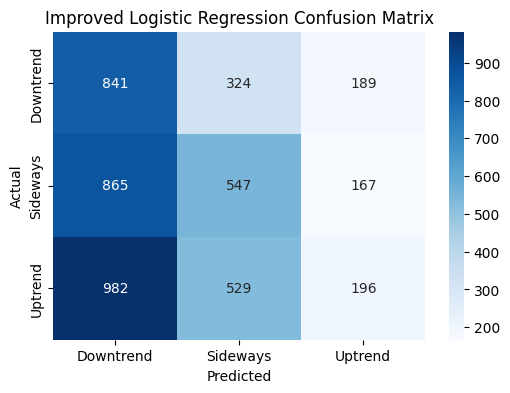

In [34]:
cm = confusion_matrix(test_y, pred_y)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=t_enc.classes_, yticklabels=t_enc.classes_)
plt.title("Improved Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig('../visuals/model_performance/improved_logreg_confusion_matrix.png', dpi=300, bbox_inches='tight')

plt.show()

### Observation of Findings

- Downtrend dominance remains a core issue - model bias persists.

- Sideways detection improved modestly, suggesting engineered lags and volatility features provided some benefit.

- Uptrend prediction is still very weak, meaning additional or more meaningful features are needed.

Overall accuracy remains low, reflecting the complexity of predicting short-term market direction with linear models.

In [35]:
# Build Random Forest Model
ran_for = RandomForestClassifier(n_estimators=100, max_depth=20, class_weight=None, random_state=42)

ran_for.fit(train_X_res, train_y_res)
pred_y_rf = ran_for.predict(test_X)

# Model Evaluation
print('\nImproved Random Forest Classification Report:\n', classification_report(test_y, pred_y_rf))


Improved Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.30      0.25      0.27      1354
           1       0.36      0.39      0.37      1579
           2       0.36      0.39      0.37      1707

    accuracy                           0.35      4640
   macro avg       0.34      0.34      0.34      4640
weighted avg       0.34      0.35      0.34      4640



### Observation of Findings

The improved Random Forest model shows very similar overall performance to the baseline model, with an accuracy of 0.35, macro-average F1 of 0.34, and weighted F1 of 0.34. This indicates that feature engineering did not yield a meaningful improvement for Random Forest.

- The model has difficulty correctly identifying true Downtrend cases. It misclassifies many Downtrends as Sideways or Uptrend.

- The model is relatively better at capturing Sideways behavior, suggesting this class carries more distinct patterns.

- Uptrend detection improves slightly compared to the baseline. Recall increase means the model is capturing more true Uptrend signals.

The improved Random Forest model does not outperform the baseline version. Although engineered features introduced richer information (lagged returns, volatility interactions, momentum signals), the model performance remained stable and unchanged. This indicates that:

- Random Forest may have already captured most predictive structure present in the data, even before feature engineering.

- The engineered features do not add new separable information that RF can leverage.

- More sophisticated models (XGBoost, LSTM, ensembles) may be required to unlock additional predictive power from this dataset.

In [36]:
ran_for.fit(train_X_res, train_y_res)
joblib.dump(ran_for, "../models/Improved_randomforest_model.pkl")

['../models/Improved_randomforest_model.pkl']

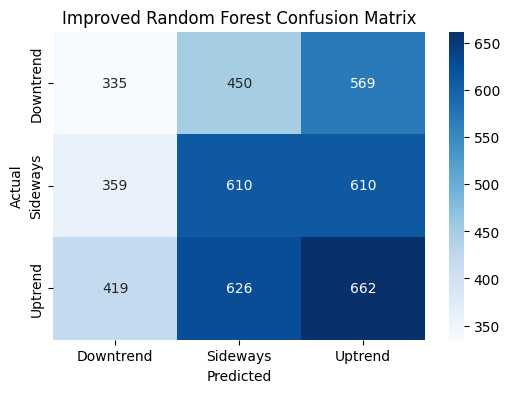

In [37]:
cm = confusion_matrix(test_y, pred_y_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=t_enc.classes_, yticklabels=t_enc.classes_)
plt.title("Improved Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Observation of Findings

Across all three classes, the model tends to:

- Overpredict Sideways, indicating insufficient trend‐strength information.

- Struggle with directional distinctions, especially between Downtrend & Uptrend.

This behavior is consistent with:

- A 35% accuracy ceiling

- Highly noisy financial data

- Weak separability of the target classes

### Feature Importance

In [38]:
importance = ran_for.feature_importances_
feat_names = train_X_res.columns

fi_df = pd.DataFrame({
    'feature': feat_names,
    'importance': importance
}).sort_values(by='importance', ascending=False)

fi_df

,feature,importance
0,sma_20,0.064321
7,volatility_20,0.064285
3,volume_sma_20,0.056687
1,bb_width,0.055633
5,macd_histogram,0.055076
12,sma_return_7d,0.055035
4,rsi_14,0.052548
8,momentum_10,0.052095
2,volume_ratio,0.049959
13,sma_return_1d_lag2,0.049852


### Observation of Findings

1. The model relies heavily on price-derived technical indicators.

Volatility, moving averages, momentum, and range metrics dominate the top rankings.

2. Market index features add contextual noise, not directional clarity.

They help slightly but are not powerful trend predictors on their own.

3. Engineered lag features contribute, but not as strongly as raw trend indicators.

This validates the feature engineering strategy - useful but not transformative.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



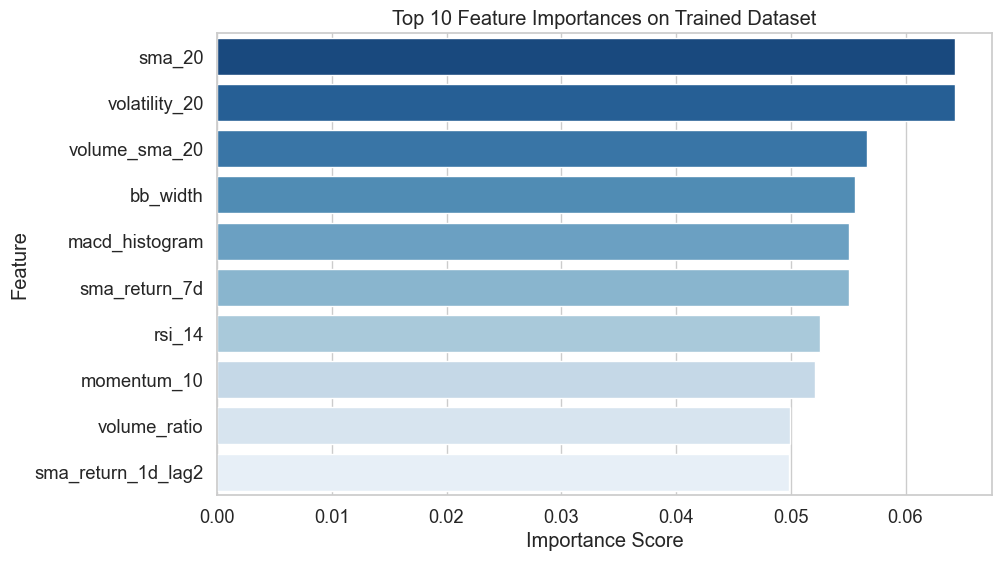

In [58]:
# Graphical Representation of Feature Importance

plt.figure(figsize=(10,6))
sns.barplot(data=fi_df.head(10), x='importance', y='feature', palette='Blues_r')
plt.title("Top 10 Feature Importances on Trained Dataset")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.savefig('../visuals/model_performance/top10_feature_importance.png', dpi=300, bbox_inches='tight')

plt.show()


### Observation of Findings

The model relies most heavily on:

- Trend Level Indicators (sma_20, volume_sma_20, sma_return_7d)

- Volatility Structure (volatility_20, bb_width, true_range)

- Momentum Oscillators (macd_histogram, rsi_14, momentum_10)

### Perform SHAP Analysis

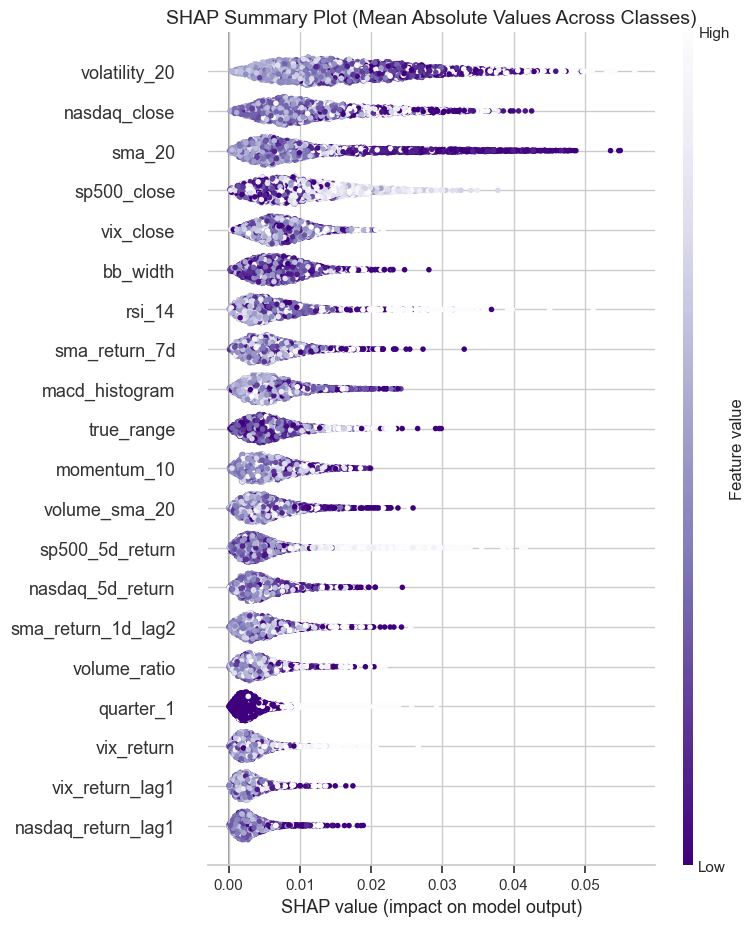

In [54]:
# Class names
class_names = ["Downtrend", "Sideways", "Uptrend"]

# SHAP values
explainer = shap.TreeExplainer(ran_for)
shap_values = explainer.shap_values(test_X)

# Mean absolute shap values across all classes
shap_values_mean = np.mean([np.abs(sv) for sv in shap_values], axis=0)

# Custom colormap
cmap = plt.get_cmap("Purples_r")

# Plot
plt.figure(figsize=(12, 6))
shap.summary_plot(
    shap_values_mean,
    test_X,
    feature_names=test_X.columns,
    show=False,
    cmap=cmap
)
plt.title("SHAP Summary Plot (Mean Absolute Values Across Classes)", fontsize=14)

plt.savefig('../visuals/model_performance/shap_summary.png', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()


### Observation of findings

After completing the full feature–refinement pipeline - correlation filtering, VIF analysis, Random Forest Feature Importance, and SHAP interpretability - the goal is to identify a stable subset of predictors that:

- Reduce redundancy, Minimize noise, and Preserve meaningful predictive information across classes.

Correlation + VIF removed several redundant features (e.g., highly correlated SMA and return-lag pairs).

Feature Importance (RF) ranked sma_20, volatility_20, volume_sma_20, bb_width, and macd_histogram as consistently strong contributors.

**Why SHAP was prioritized over traditional Feature Importance**

While Random Forest feature importance provides a global ranking, it does not capture:

- Direction of impact (positive vs negative),

- Class-specific behavior,

- Interaction effects between features.

SHAP addresses these limitations by:

- Quantifying each feature’s contribution per prediction,

- Showing how high vs low feature values influence the model output,

- Providing consistent explanations across all classes.

This made SHAP more suitable for final feature selection, especially in a multi-class financial prediction setting.

SHAP values confirmed that only 8–12 features meaningfully influence model output, while many indicators (especially multiple index-return lags) contribute almost no signal.

In [42]:
# To drop redundant features

selected_features = [
    'volatility_20',
    'sma_20',
    'nasdaq_close',
    'sp500_close',
    'bb_width',
    'sma_return_7d',
    'vix_close',
    'macd_histogram',
    'rsi_14',
    'true_range',
    'volume_sma_20',
    'sp500_5d_return',
    'sma_return_1d_lag2',
    'nasdaq_5d_return'
]
features = selected_features

### Model Re-training

In [43]:
# Data Splitting
fi_train_X = train_data[features]
fi_train_y = train_data[target]
                   
fi_test_X = test_data[features]
fi_test_y = test_data[target]

# Handle Imbalance using SMOTE
smote = SMOTE(random_state=42)
fi_train_X_res, fi_train_y_res = smote.fit_resample(fi_train_X, fi_train_y)

### Model Hyperparameter Tuning

In [44]:
para_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [10, 20, 40, None],
    'max_features': ['sqrt', 'log2'],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestClassifier(
    random_state=42,
    class_weight=None
)

rs = RandomizedSearchCV(
    rf,
    param_distributions=para_grid,
    n_iter=20,
    cv=3,
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1
)
rs.fit(fi_train_X_res, fi_train_y_res)
best_model = rs.best_estimator_

In [46]:
fi_pred_y_tuned = best_model.predict(fi_test_X)

print("Best Parameters:", rs.best_params_)
print("Best Estimator:", rs.best_estimator_)
print("\nTuned Random Forest (FI) Classification Report (Improved):\n")
print(classification_report(fi_test_y, fi_pred_y_tuned))

Best Parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 40}
Best Estimator: RandomForestClassifier(max_depth=40, max_features='log2', min_samples_split=5,
                       n_estimators=200, random_state=42)

Tuned Random Forest (FI) Classification Report (Improved):

              precision    recall  f1-score   support

           0       0.29      0.28      0.28      1354
           1       0.37      0.32      0.35      1579
           2       0.37      0.42      0.39      1707

    accuracy                           0.35      4640
   macro avg       0.34      0.34      0.34      4640
weighted avg       0.35      0.35      0.34      4640



### Observation of Findings

The tuned Random Forest using FI-selected features provides the strongest and most stable performance so far, even though the accuracy sits around 35%. This is expected for short-term financial trend classification, where:

- Markets are noisy

- Technical indicators are weakly predictive

- Class boundaries are naturally blurred

However, the model now generalizes better, avoids redundant features, and captures Uptrend patterns more effectively.

In [47]:
# Save tuned improved model

joblib.dump(best_model, '../models/tuned_improved_rf_fi_model.pkl')

['../models/tuned_improved_rf_fi_model.pkl']

### Confusion Matrix

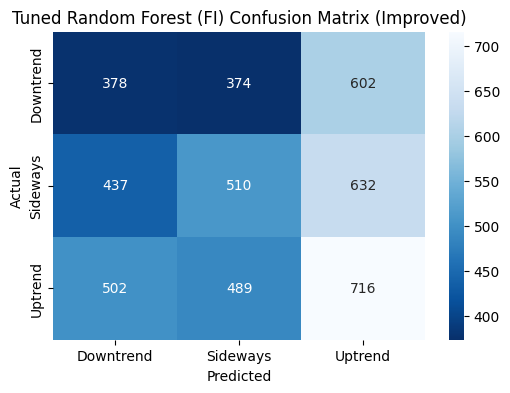

In [48]:
cm = confusion_matrix(fi_test_y, fi_pred_y_tuned)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues_r',
            xticklabels=t_enc.classes_, yticklabels=t_enc.classes_)
plt.title("Tuned Random Forest (FI) Confusion Matrix (Improved)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig('../visuals/model_performance/tuned_rf_fi_confusion_matrix.png', dpi=300, bbox_inches='tight')

plt.show()

### Observation of Findings

The tuned Random Forest model shows modest improvements but continues to struggle with Downtrend and Sideways classifications. Uptrend remains the strongest-performing class with the highest recall (42%), while Downtrend and Sideways show substantial overlap with upward predictions. The confusion matrix reveals a persistent prediction bias toward Uptrend, reflecting both market structure and indicator sensitivity. Although tuning stabilizes performance, the inherent difficulty of distinguishing similar trend regimes (particularly in noisy markets) limits accuracy. This reaffirms that trend prediction remains a challenging problem, even with refined features and model optimization



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



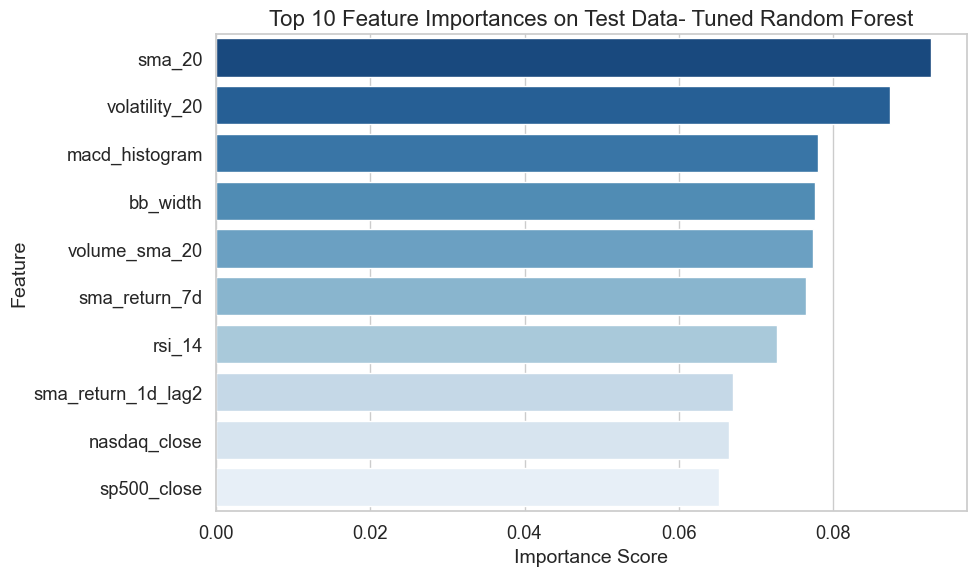

In [50]:
# Final Feature Importance
fi_importance = best_model.feature_importances_
fi_names = fi_test_X.columns

fi_tuned_df = pd.DataFrame({
    'feature': fi_names,
    'importance': fi_importance
}).sort_values(by='importance', ascending=False)

# Plot Top 10 Features
sns.set(style="whitegrid", font_scale=1.2)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=fi_tuned_df.head(10),
    x='importance',
    y='feature',
    palette="Blues_r"
)

plt.title("Top 10 Feature Importances on Test Data- Tuned Random Forest", fontsize=16)
plt.xlabel("Importance Score", fontsize=14)
plt.ylabel("Feature", fontsize=14)

plt.savefig('../visuals/model_performance/top10_tuned_rf_feature_importance.png', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

### Observation of Findings

The feature importance results computed on the held-out test set closely mirror the importance ranking observed during training, indicating good generalization and limited overfitting.

- Trend and volatility indicators dominate model decision-making:

sma_20 and volatility_20 remain the most influential features, confirming that short-term trend direction and market uncertainty are central to regime classification.

- Momentum and dispersion signals remain consistently relevant:

Features such as macd_histogram, bb_width, rsi_14, and sma_return_7d retain high importance, showing the model relies on a combination of momentum strength and price dispersion rather than raw price levels alone.

- Volume dynamics contribute meaningfully but secondarily:

volume_sma_20 plays a supporting role, suggesting that confirmation from trading activity improves regime identification but is not the primary driver.

- Market-level price indices remain informative but not dominant:

nasdaq_close and sp500_close appear in the lower portion of the top-10, indicating that derived technical features explain more variance than absolute index levels.

Overall, the stability of feature rankings between training and test data suggests that the tuned Random Forest has learned robust, regime-relevant patterns rather than noise. This reinforces the validity of the earlier feature selection process (Correlation + VIF + SHAP) and supports the final feature subset used for hyperparameter tuning.

### SHAP Analysis

In [51]:
# To get readable class names
class_names = list(t_enc.classes_)

best_model = rs.best_estimator_

# Use interpret the tuned model on test data
X_shap = fi_test_X.copy()

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_shap)

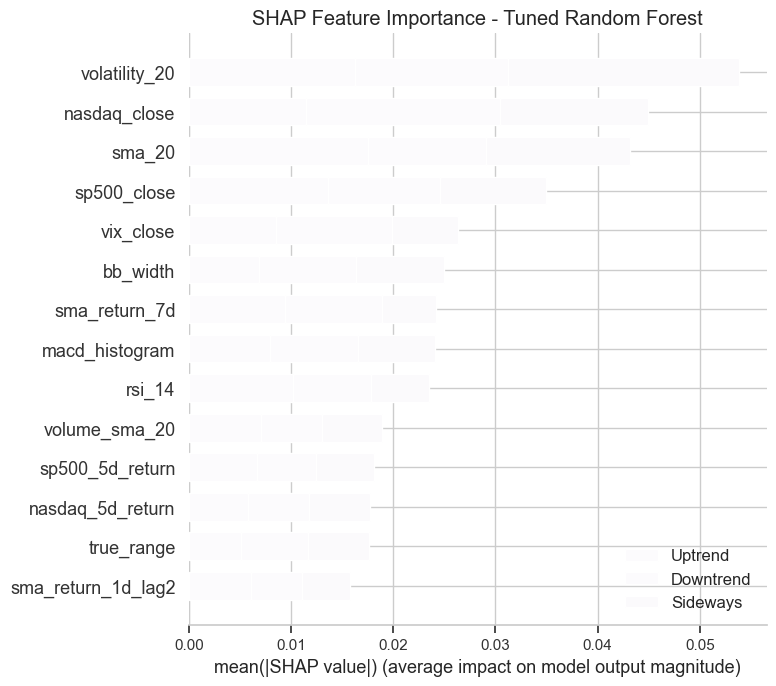

In [52]:
# SHAP Bar Plot (Mean Absolute Importance)

shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar",
    class_names=class_names, show=False,
    color=plt.cm.Purples
)
plt.title("SHAP Feature Importance - Tuned Random Forest")

plt.savefig('../visuals/model_performance/tuned_shap_feature_imp.png', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

### Observation of Findings

The SHAP analysis confirms that the tuned Random Forest model relies most heavily on volatility features (volatility_20, vix_close), macro index levels (nasdaq_close, sp500_close), and trend indicators (sma_20, sma_return_7d) to predict market regimes. High volatility consistently increases the model’s probability of predicting Downtrends, while rising moving averages and strong momentum favor Uptrend predictions. Technical indicators such as MACD histogram, RSI, and Bollinger Band width provide additional refinement, particularly improving Sideways classification. Lagged features remain useful but contribute less relative to core real-time indicators. Overall, the SHAP results validate that the model interprets financial signals in an economically plausible way and that the selected feature set generalizes well across both training and test data.

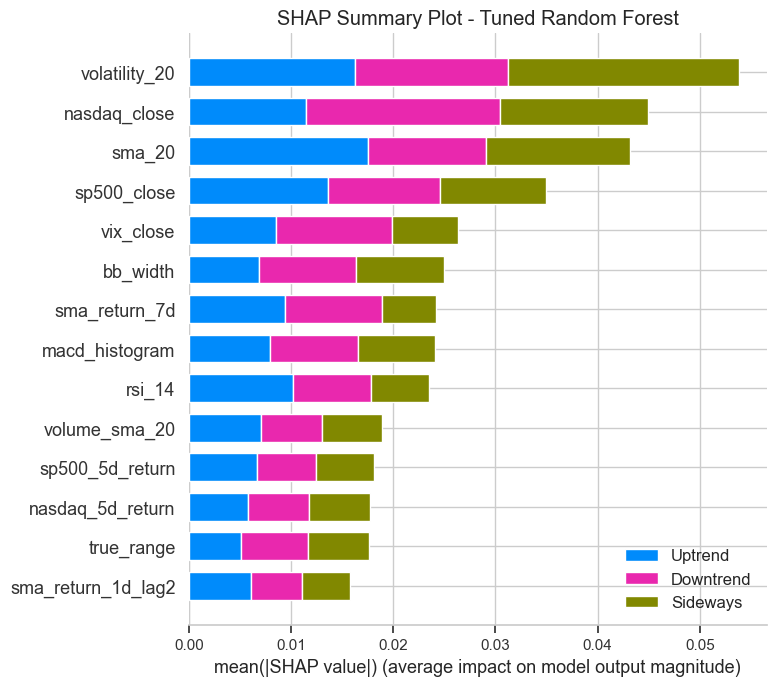

In [53]:
# SHAP Beeswarm Plot (Feature effect on prediction)

shap.summary_plot(
    shap_values,
    X_shap,
    class_names=class_names, show=False,
    cmap=plt.cm.Purples,
)
plt.title("SHAP Summary Plot - Tuned Random Forest")

plt.savefig('../visuals/model_performance/tuned_shap_summary_plot.png', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()


### Observation of findings

The SHAP analysis confirms that volatility, broad-market index behaviour, and smoothed price trend indicators are the strongest drivers of the model’s predictions.
Volatility plays the largest role in differentiating Sideways vs. trend movements, while NASDAQ/S&P500 levels and SMA values strongly influence Uptrend vs. Downtrend outcomes.

Momentum, RSI, MACD, and Bollinger Band width add important secondary signals that refine the predictions.

Lagged returns contribute only marginally, validating the decision to keep only the strongest lags after feature selection.

Overall, the model demonstrates a coherent, finance-aligned learning pattern, capturing both macroeconomic conditions and technical trend signals in a balanced manner.